In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../dataset/cleaned_ri_matches.csv')

print("Dataset Overview:")
print(f"Total rows: {len(df)}")
print(f"Unique award names: {df['awardname'].nunique()}")
print(f"Year range: {df['awardreceivedawardyear'].min()} to {df['awardreceivedawardyear'].max()}")
print(f"Prestige levels: {', '.join(df['prestige'].unique())}")
print("\n")

common_awards = df['awardname'].value_counts()
common_awards = common_awards[common_awards >= 10]
print(f"Number of awards appearing 10+ times: {len(common_awards)}")

award_prestige = pd.crosstab(
    df[df['awardname'].isin(common_awards.index)]['awardname'], 
    df[df['awardname'].isin(common_awards.index)]['prestige'],
    normalize='index'
)

print("\nTop 5 awards most likely to be 'Highly Prestigious':")
print(award_prestige.sort_values('Highly Prestigious', ascending=False).head(5)['Highly Prestigious'])

print("\nTop 5 awards most likely to be 'Prestigious':")
print(award_prestige.sort_values('Prestigious', ascending=False).head(8)['Prestigious'])

Dataset Overview:
Total rows: 2403
Unique award names: 949
Year range: 1900 to 2025
Prestige levels: Not Designated, Prestigious, Highly Prestigious


Number of awards appearing 10+ times: 31

Top 5 awards most likely to be 'Highly Prestigious':
awardname
NEH Fellowships for University Teachers                                                                                 1.000000
American Academy of Arts and Sciences Member/Fellow                                                                     1.000000
ACLS Fellows (ACLS/SSRC/NEH International and Area Studies Fellowships and ACLS/New York Public Library Fellowships)    1.000000
Guggenheim Fellowship                                                                                                   1.000000
Fellow                                                                                                                  0.033708
Name: Highly Prestigious, dtype: float64

Top 5 awards most likely to be 'Prestigious':
awardname
A


Keyword patterns in award names:
  keyword  count  avg_prestige
4   Medal     16      0.687500
0  Fellow    828      0.497585
2   Prize     95      0.368421
1   Award    704      0.129261
3   Grant    177      0.062147


Text(0, 0.5, 'Avg Prestige Score (0-2)')

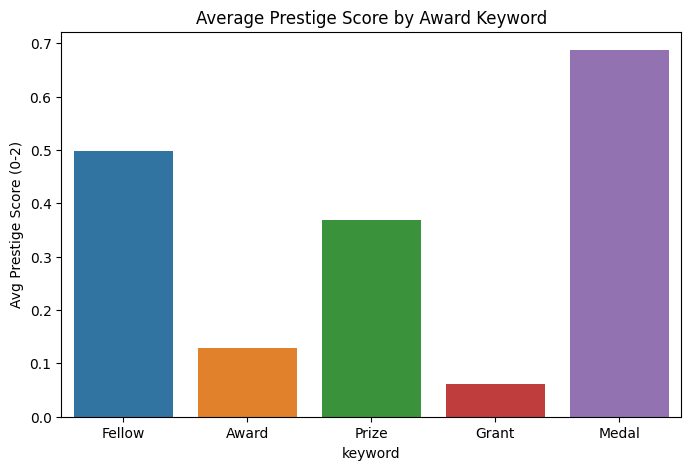

In [36]:
prestige_map = {
    'Not Designated': 0, 
    'Prestigious': 1, 
    'Highly Prestigious': 2
}
df['prestige_score'] = df['prestige'].map(prestige_map)

yearly_prestige = df.groupby('awardreceivedawardyear')['prestige_score'].agg(['mean', 'count'])
yearly_prestige = yearly_prestige[yearly_prestige['count'] >= 10]

keywords = ["Fellow", "Award", "Prize", "Grant", "Medal"]
keyword_results = []

for keyword in keywords:
    keyword_rows = df[df['awardname'].str.contains(keyword, case=False)]
    avg_prestige = keyword_rows['prestige_score'].mean()
    keyword_results.append({
        'keyword': keyword,
        'count': len(keyword_rows),
        'avg_prestige': avg_prestige
    })

keyword_df = pd.DataFrame(keyword_results)
print("\nKeyword patterns in award names:")
print(keyword_df.sort_values('avg_prestige', ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(x='keyword', y='avg_prestige', data=keyword_df)
plt.title('Average Prestige Score by Award Keyword')
plt.ylabel('Avg Prestige Score (0-2)')

Awards with Signficant Changes Over Time

In [37]:
award_counts = df['awardname'].value_counts()
common_awards = award_counts[award_counts >= 10].index.tolist()

df['decade'] = df['awardreceivedawardyear'].apply(
    lambda year: 'pre-1980' if year == 1900 or year < 1980 
    else f"{(year // 10) * 10}s"
)

df_common = df[df['awardname'].isin(common_awards)]

decades = sorted(df_common['decade'].unique())
trend_decades = [d for d in decades if d != 'pre-1980']


significant_awards = award_counts[award_counts >= 20].index.tolist()

award_trends = {}
for award in significant_awards:
    decade_data = []
    
    for decade in trend_decades:
        decade_df = df_common[df_common['decade'] == decade]
        total_in_decade = len(decade_df)
        award_in_decade = len(decade_df[decade_df['awardname'] == award])
        
        if award_in_decade > 0 and total_in_decade > 0:
            percentage = (award_in_decade / total_in_decade) * 100
            decade_data.append({
                'decade': decade,
                'count': award_in_decade,
                'percentage': percentage
            })
    
    if len(decade_data) >= 3:
        first = decade_data[0]
        last = decade_data[-1]
        trend = last['percentage'] - first['percentage']
        
        award_trends[award] = {
            'award': award,
            'trend': trend,
            'first_decade': first['decade'],
            'last_decade': last['decade'],
            'first_percentage': f"{first['percentage']:.1f}%",
            'last_percentage': f"{last['percentage']:.1f}%",
            'decade_data': decade_data
        }

sorted_trends = sorted(award_trends.values(), key=lambda x: abs(x['trend']), reverse=True)

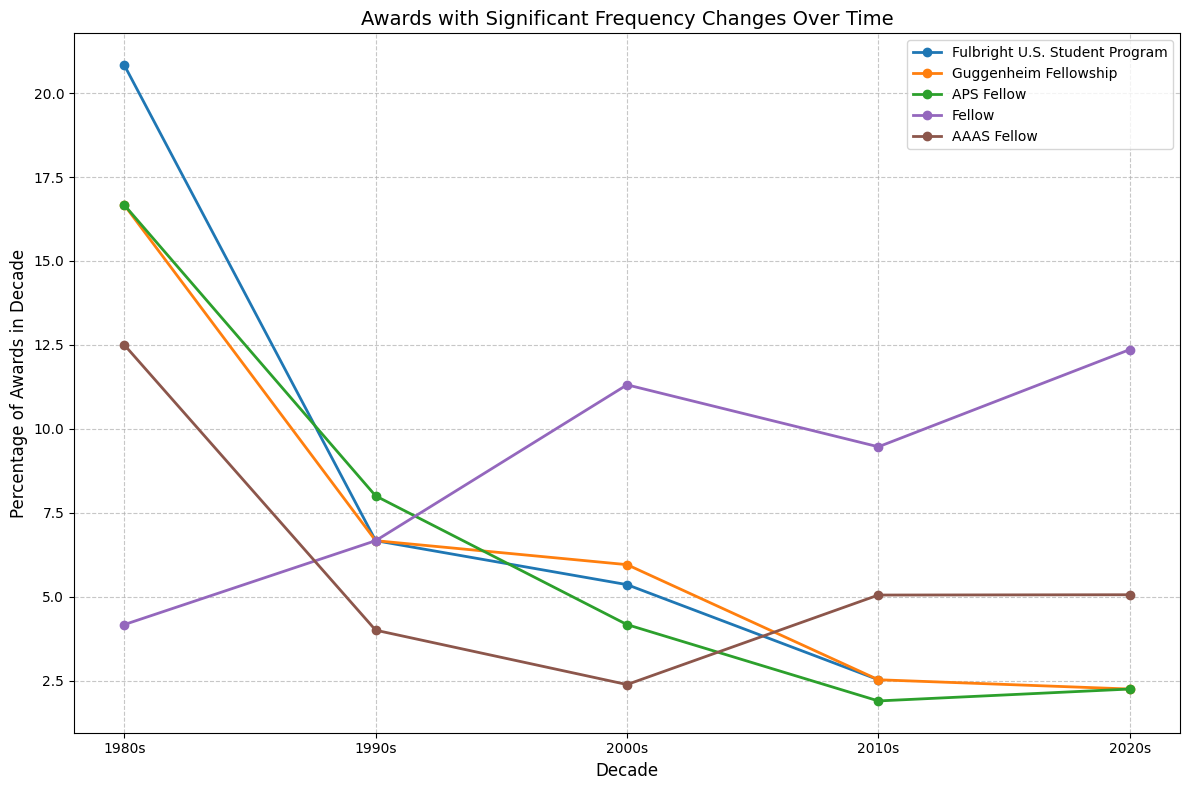

In [38]:
plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, 8))

for i, item in enumerate(sorted_trends[:5]):
    decades_list = [d['decade'] for d in item['decade_data']]
    percentages = [d['percentage'] for d in item['decade_data']]
    
    plt.plot(decades_list, percentages, marker='o', linewidth=2, color=colors[i], label=item['award'])

plt.title("Awards with Significant Frequency Changes Over Time", fontsize=14)
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Percentage of Awards in Decade", fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Top 5 awards per decade

In [39]:
decades = sorted(df_common['decade'].unique())
top_awards_by_decade = {}

for decade in decades:
    decade_df = df_common[df_common['decade'] == decade]
    decade_counts = decade_df['awardname'].value_counts()
    decade_pct = decade_df['awardname'].value_counts(normalize=True) * 100
    
    top_awards = []
    for award, count in decade_counts.head(5).items():
        percentage = decade_pct[award]
        top_awards.append({
            'award': award,
            'percentage': percentage
        })
    
    top_awards_by_decade[decade] = top_awards

all_top_awards = set()
for decade in decades:
    for item in top_awards_by_decade[decade]:
        all_top_awards.add(item['award'])

color_map = {}
colors = plt.cm.tab20(np.linspace(0, 1, len(all_top_awards)))
for i, award in enumerate(sorted(all_top_awards)):
    color_map[award] = colors[i]

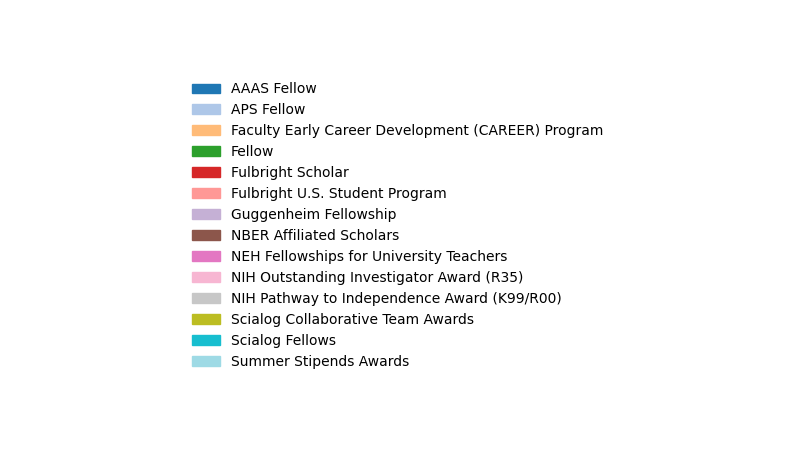

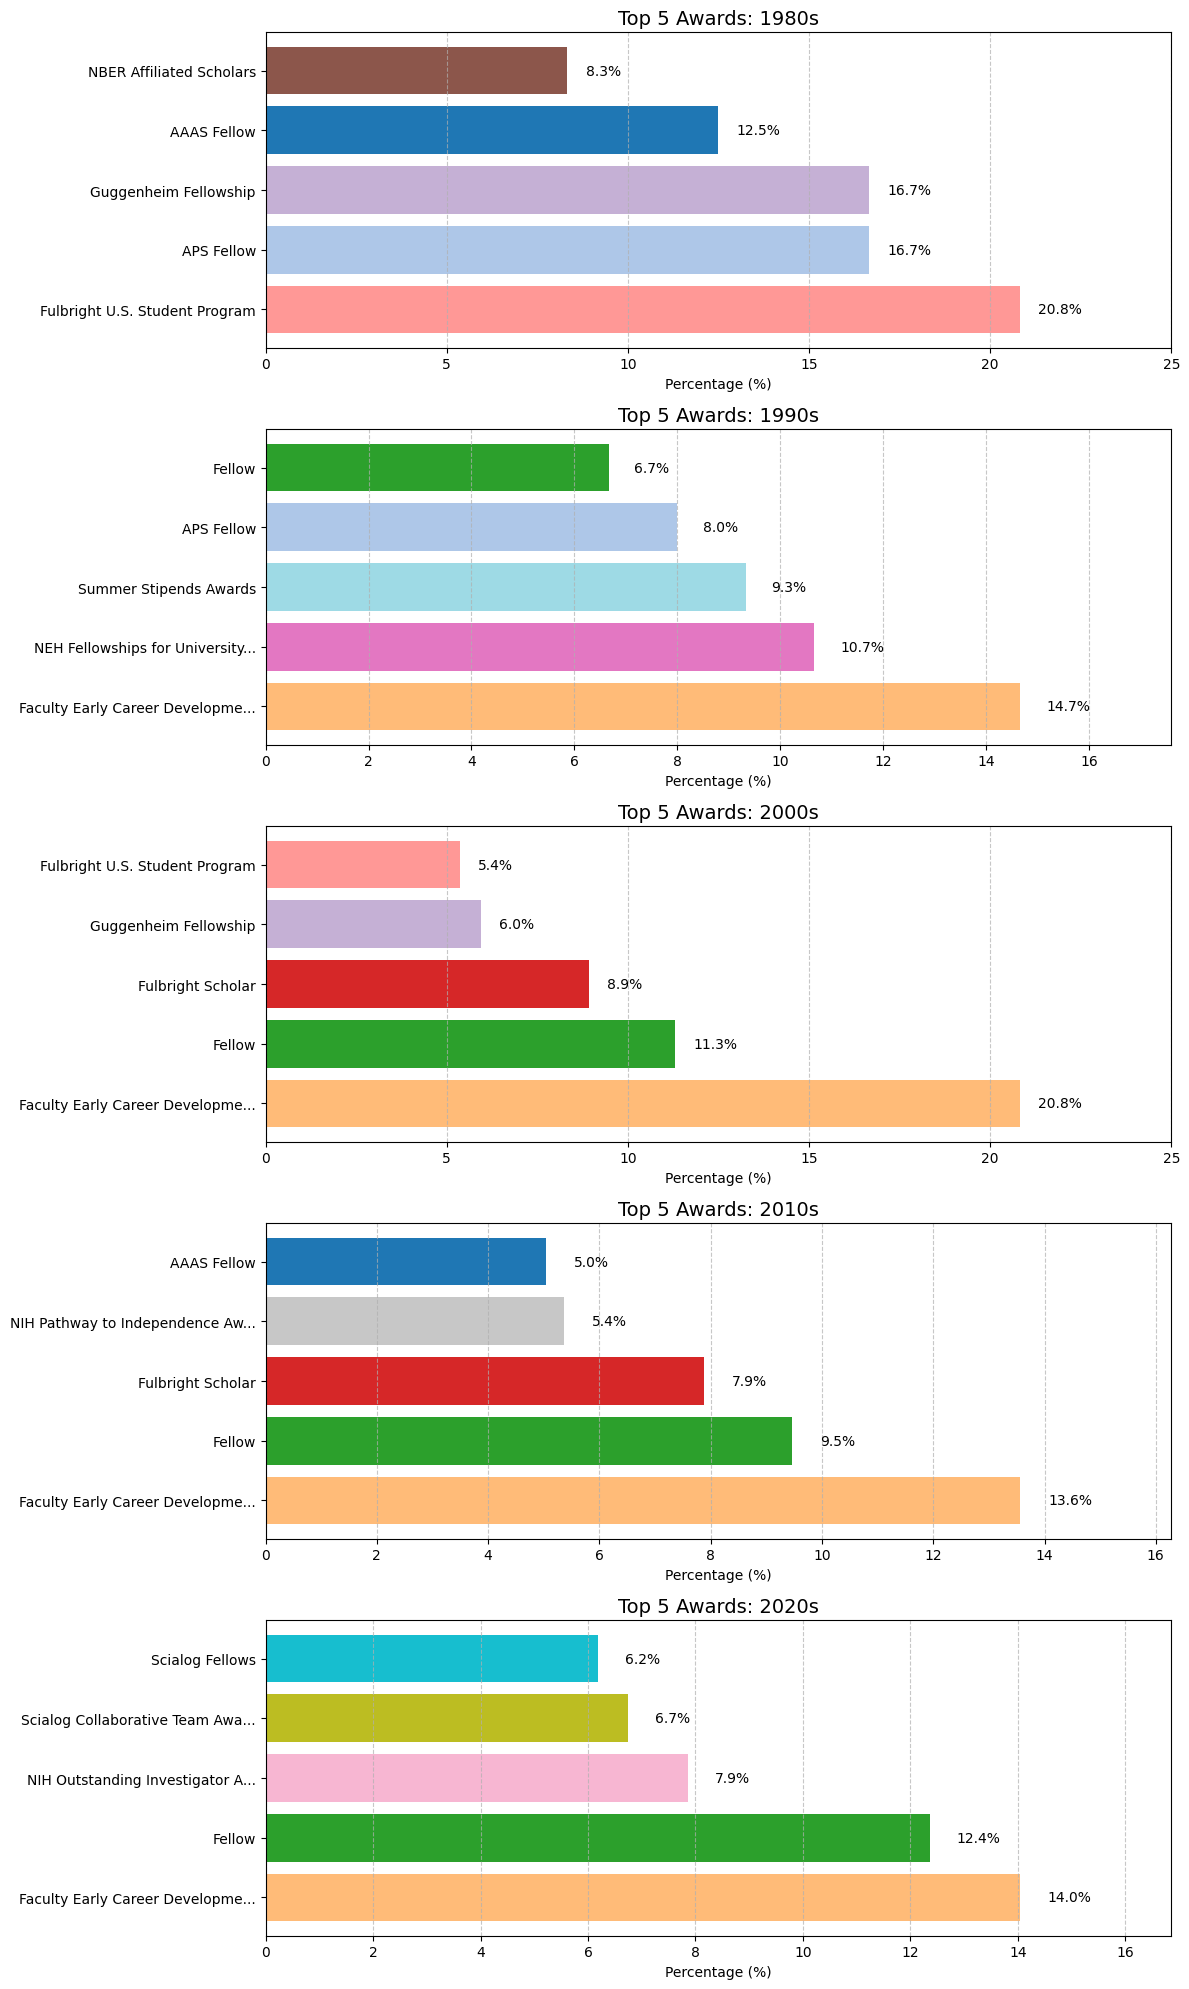

In [34]:
fig, axes = plt.subplots(len(decades), 1, figsize=(12, 4*len(decades)))

for i, decade in enumerate(sorted(decades)):
    ax = axes[i]
    awards = [item['award'] for item in top_awards_by_decade[decade]]
    percentages = [item['percentage'] for item in top_awards_by_decade[decade]]
    short_awards = [award[:30] + '...' if len(award) > 30 else award for award in awards]
    award_colors = [color_map[award] for award in awards]
    bars = ax.barh(short_awards, percentages, color=award_colors)
    
    for bar, pct in zip(bars, percentages):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{pct:.1f}%', va='center')
    
    ax.set_title(f'Top 5 Awards: {decade}', fontsize=14)
    ax.set_xlabel('Percentage (%)')
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.set_xlim(0, max(percentages) * 1.2)

legend_fig, legend_ax = plt.subplots(figsize=(10, len(all_top_awards) * 0.4))
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[award]) for award in sorted(all_top_awards)]
legend_ax.legend(legend_handles, sorted(all_top_awards), loc='center', frameon=False)
legend_ax.axis('off')

plt.figure(fig.number)
plt.tight_layout()